# UGRID unstructured-mesh files

Unstructured meshes follow the UGRID convention and use the `UgridDataset` API (nodes, faces, connectivity) rather than the gridded raster API.

In [1]:
%matplotlib inline
from pathlib import Path

from shapely.geometry import Polygon, box

from pyramids.netcdf import NetCDF, UgridDataset

DATA = Path('../../../../examples/data/netcdf/samples')

**Cropping a mesh.** `UgridDataset.crop` spatially subsets an unstructured mesh: it keeps the faces that fall inside a polygon (`mask=`) or a bounding box (`bbox=`) — the mesh analogue of the affine raster crop shown in `01`–`03`. Pass `touch=True` to keep every face that touches the region, or `touch=False` to keep only the faces fully inside it. The result is a smaller `UgridDataset` with the surviving nodes/faces (and any face/node data) renumbered.

## `ugrid__6v__1d5-2d1.nc` — a 2-D face/node mesh

A UXARRAY-style mesh declaring topology via `cf_role` on the connectivity variable.

**Open the mesh**

In [2]:
ug = UgridDataset.read_file(DATA / 'ugrid__6v__1d5-2d1.nc')
ug

UgridDataset(mesh='mesh2d', n_node=16, n_face=4, n_edge=0, variables=[])

**Mesh dimensions**

In [3]:
print('nodes:', ug.n_node, '| faces:', ug.n_face, '| edges:', ug.n_edge)
print('mesh:', ug.mesh)
print('bounds:', ug.bounds)

nodes: 16 | faces: 4 | edges: 0
mesh: <pyramids.netcdf.ugrid.mesh.Mesh2d object at 0x0000022C72303E00>
bounds: (-0.3252372145652771, -0.26931479573249817, 0.38283485174179077, 0.2782424986362457)


**Plot the mesh outline**

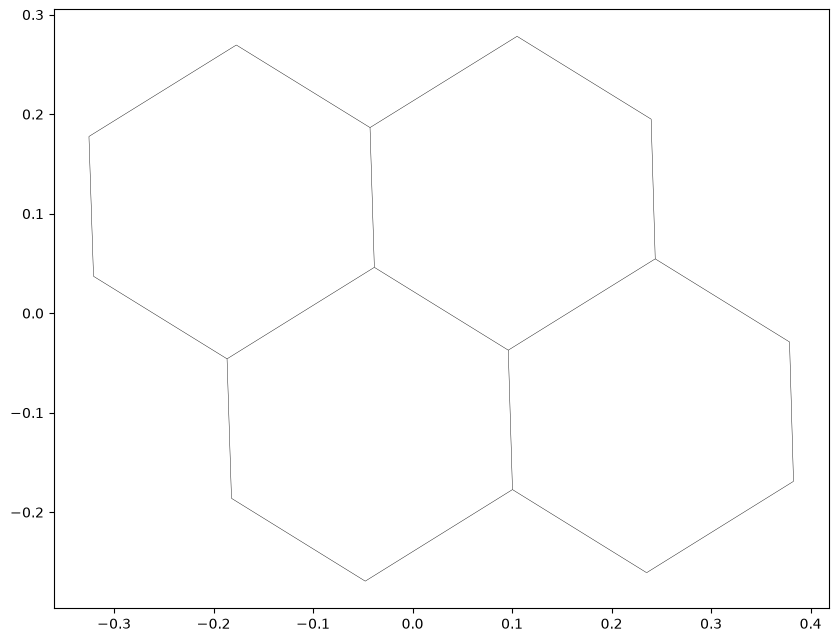

In [4]:
ug.plot_outline()

**Face polygons as a GeoDataFrame**

In [5]:
ug.to_geodataframe()

,geometry
0,"POLYGON ((-0.03841 0.04606, -0.18645 -0.0459, ..."
1,"POLYGON ((0.24388 0.05458, 0.23977 0.19501, 0...."
2,"POLYGON ((-0.03841 0.04606, -0.04275 0.18654, ..."
3,"POLYGON ((0.1004 -0.1773, 0.23522 -0.26082, 0...."


**Crop the mesh to a bounding box**


Build a rectangular region over part of the mesh and keep the faces that touch it. On a real dataset this box would be a country/region envelope; this sample mesh lives in abstract coordinates, so we use its own extent.


In [6]:
# A bounding-box polygon over the right-hand portion of the mesh
region = box(0.0, -0.3, 0.4, 0.3)

In [7]:
# Keep every face that touches the region
cropped = ug.crop(region, touch=True)

In [8]:
# Cropping selects a subset of the faces
print('faces before:', ug.n_face, '| faces after crop:', cropped.n_face)

faces before: 4 | faces after crop: 3


**Plot the cropped mesh outline**


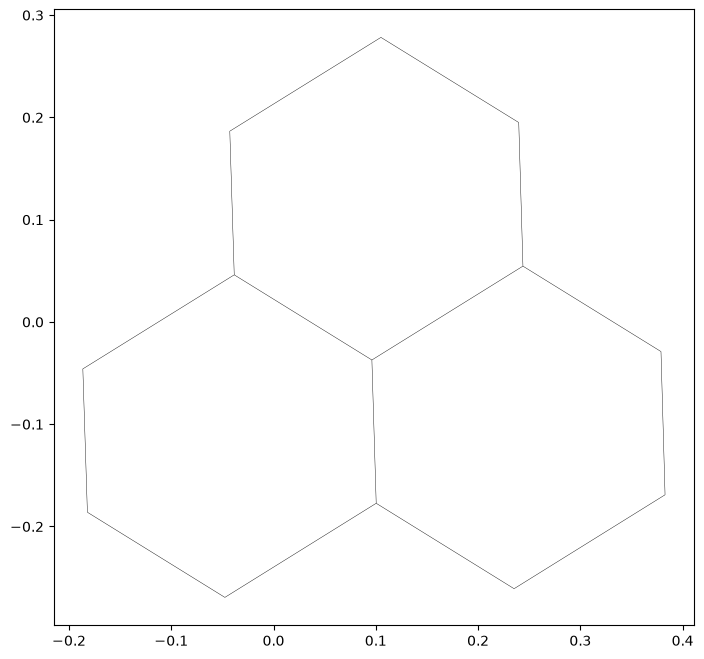

In [9]:
cropped.plot_outline()

`crop` also accepts a bounding box directly via `bbox=(xmin, ymin, xmax, ymax)`, equivalent to `subset_by_bounds`:


In [10]:
# Same subset expressed as a bounding box instead of a polygon mask
cropped_bbox = ug.crop(bbox=(0.0, -0.3, 0.4, 0.3))
print('faces inside bbox:', cropped_bbox.n_face)

faces inside bbox: 2


**Keep only fully-contained faces with `touch=False`**


`touch=True` (the default) keeps every face that *touches* the region, including those straddling its boundary. `touch=False` is stricter — it keeps only the faces that lie **entirely inside** the region, so it returns the same or fewer faces.


In [11]:
# Re-crop the same box, this time keeping only faces fully inside it
inside_only = ug.crop(region, touch=False)
print('touch=True :', cropped.n_face, 'faces')
print('touch=False:', inside_only.n_face, 'faces')

touch=True : 3 faces
touch=False: 1 faces


**Crop with an arbitrary polygon mask**


The mask is not limited to a rectangle — any shapely polygon works. Here a triangular area of interest selects the faces it overlaps.


In [12]:
# A triangular region over the lower-left of the mesh
triangle = Polygon([(-0.35, -0.3), (0.05, -0.3), (-0.35, 0.3)])

In [13]:
# Keep the faces the triangle touches
triangle_crop = ug.crop(triangle, touch=True)
print('faces inside the triangle:', triangle_crop.n_face)

faces inside the triangle: 2


**Plot the triangle-cropped mesh outline**


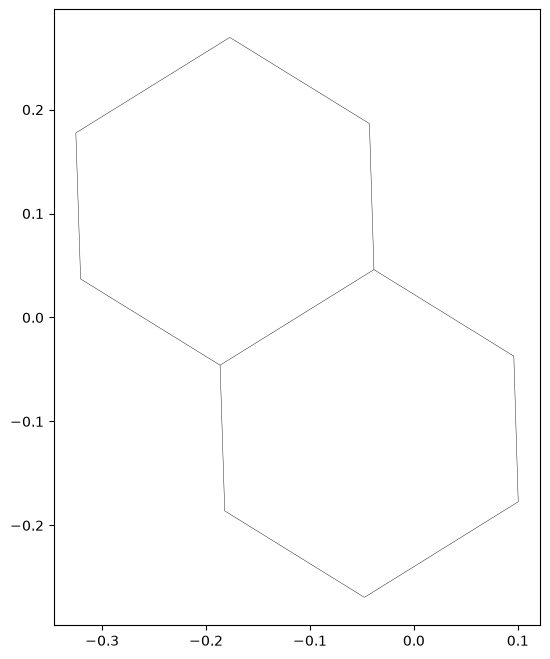

In [14]:
triangle_crop.plot_outline()

## Data-only UGRID files

`ugrid__1v__3d1.nc` and `ugrid__1v__1d1.nc` carry data on a mesh dimension but no topology variable, so they are opened with the regular `NetCDF` reader.

In [15]:
nc = NetCDF.read_file(DATA / 'ugrid__1v__3d1.nc')
print('variables:', nc.variable_names)
print('dimensions:', dict(nc.dimension_sizes))

variables: ['multi_dim_data']
dimensions: {'time': 8, 'lev': 8, 'n_face': 4}


In [16]:
nc = NetCDF.read_file(DATA / 'ugrid__1v__1d1.nc')
print('variables:', nc.variable_names)
print('dimensions:', dict(nc.dimension_sizes))

variables: ['psi']
dimensions: {'ncol': 5400}
